In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Loading the Netflix Dataset
netflix_df = pd.read_csv('/content/drive/MyDrive/CAPSTONE PROJECT/Netflix Dataset.csv')



In [ ]:
# Stripping extra spaces from Column Names
netflix_df.columns = netflix_df.columns.str.strip()

In [ ]:
#Check Null values
print(netflix_df.isnull().sum())

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64


In [ ]:
# Replacing Director, Cast, and Country with 'Unknown'
netflix_df.fillna({'Director': 'Unknown', 'Cast': 'Unknown', 'Country': 'Unknown'}, inplace=True)

In [ ]:
# Droping the  Null values of Release_Date and Rating
netflix_df.dropna(subset=['Release_Date', 'Rating'], inplace=True)

In [ ]:
# Delete Duplicates
netflix_df = netflix_df.drop_duplicates()

In [ ]:
# Convert 'Release_Date' to pd.to_datetime
netflix_df['Release_Date'] = pd.to_datetime(netflix_df['Release_Date'], format='%d %B %Y', errors='coerce')


In [ ]:
# Extract the column Year
netflix_df['Year_Added'] = netflix_df['Release_Date'].dt.year

In [ ]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7788
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Show_Id       7770 non-null   object        
 1   Category      7770 non-null   object        
 2   Title         7770 non-null   object        
 3   Director      7770 non-null   object        
 4   Cast          7770 non-null   object        
 5   Country       7770 non-null   object        
 6   Release_Date  0 non-null      datetime64[ns]
 7   Rating        7770 non-null   object        
 8   Duration      7770 non-null   object        
 9   Type          7770 non-null   object        
 10  Description   7770 non-null   object        
 11  Year_Added    0 non-null      float64       
dtypes: datetime64[ns](1), float64(1), object(10)
memory usage: 789.1+ KB


TOTAL NUMBER OF SHOWS

In [ ]:
# KPI — Total Shows
total_shows = netflix_df['Show_Id'].count()
print("Total Shows on Netflix:", total_shows)

Total Shows on Netflix: 7770


TOP 10 DIRECTORS

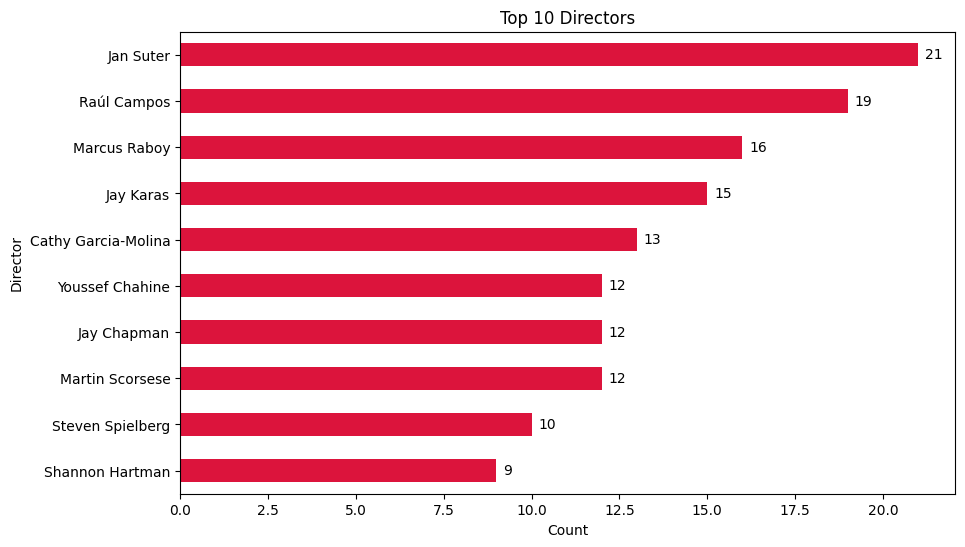

In [ ]:
# Top 10 Directors
top_director = netflix_df[netflix_df['Director'] != 'Unknown']['Director'].dropna().str.split(', ').explode().value_counts().head(10).sort_values(ascending=True)

# Plotting the top 10 directors
plt.figure(figsize=(10, 6))
top_director.plot(kind='barh', color='Crimson')
plt.title('Top 10 Directors')
plt.xlabel('Count')
plt.ylabel('Director')
plt.bar_label(plt.gca().containers[0], padding=5)
plt.show()

TOP 10 CAST

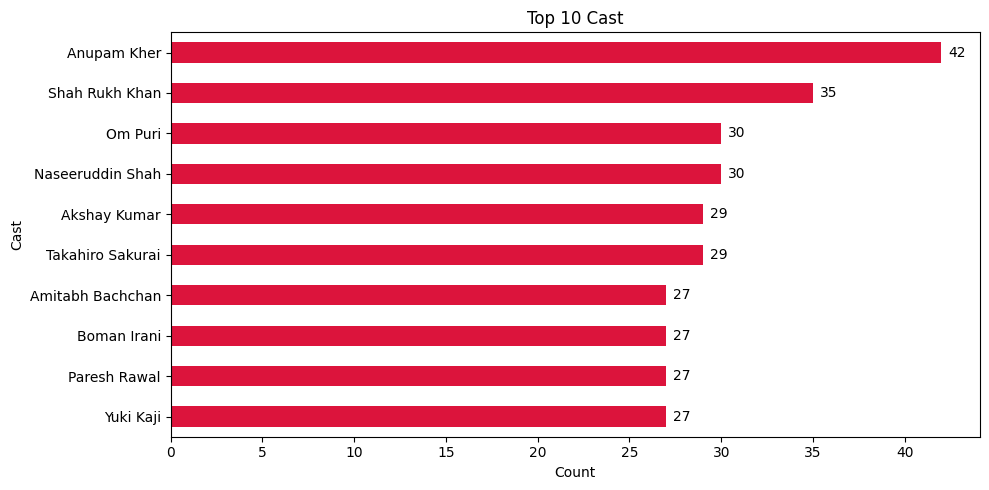

In [ ]:
# Top 10 Cast
top_Cast = netflix_df[netflix_df['Cast'] != 'Unknown']['Cast'].dropna().str.split(', ').explode().value_counts().head(10).sort_values(ascending=True)

# Plotting
plt.figure(figsize=(10, 5))
top_Cast.plot(kind='barh', color='Crimson')
plt.title('Top 10 Cast')
plt.xlabel('Count')
plt.ylabel('Cast')
plt.bar_label(plt.gca().containers[0],padding=5)
plt.tight_layout()
plt.show()

CATEGORY WISE DISTRIBUTION

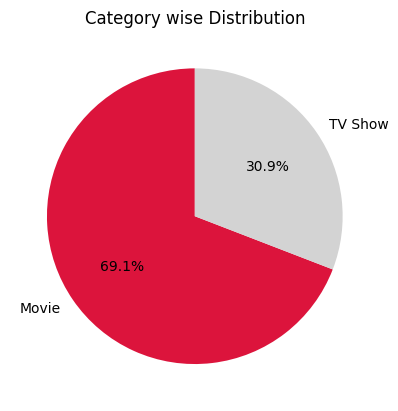

In [ ]:
#Category Wise Distribution
Category_counts= netflix_df['Category'].value_counts()

# Plotting the Category wise Distribution
Category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['Crimson', 'LightGrey'] )
plt.title('Category wise Distribution')
plt.ylabel('')
plt.show()

YEAR WISE CATEGORY DISTRIBUTION OF MOVIES VS TV SHOWS

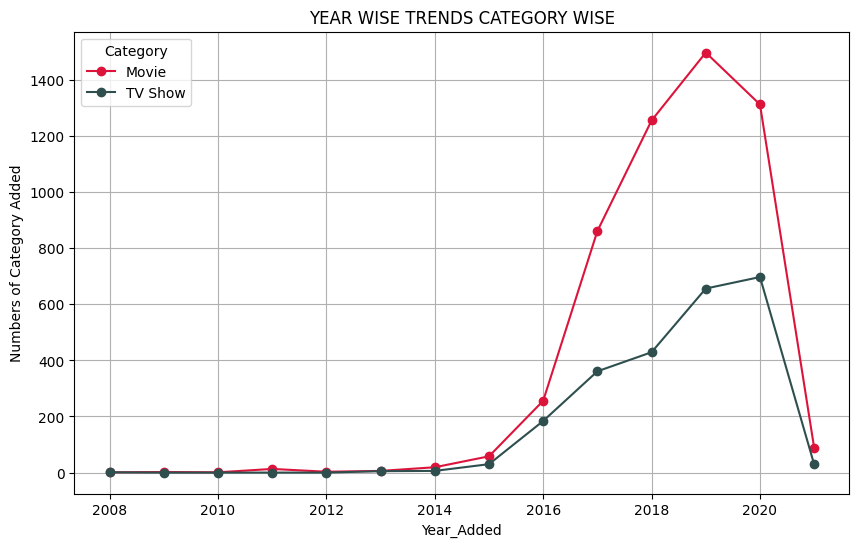

In [ ]:
# Year wise Category distribution of Movies Vs Tv Show
yearwise_category = ( netflix_df.groupby('Year_Added')['Category'].value_counts() .unstack() .fillna(0) )

# Plotting the Same
yearwise_category.plot(kind='line', marker='o',color={'Movie':'crimson','TV Show':'DarkSlateGray'},figsize=(10, 6))
plt.title('YEAR WISE TRENDS CATEGORY WISE')
plt.xlabel('Year_Added')
plt.ylabel('Numbers of Category Added')
plt.legend(title='Category')
plt.grid(True)
plt.show()

YEAR WISE TOTAL SHOWS

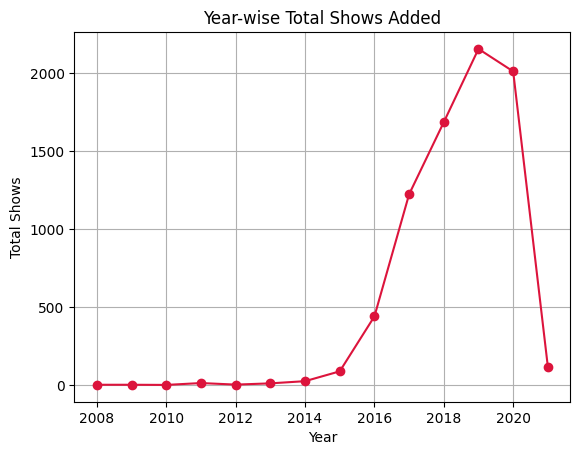

In [ ]:
# Year Wise Total Shows
total_shows_counts = netflix_df['Year_Added'].value_counts().sort_index()

# Plotting the Same
total_shows_counts.plot(kind='line', marker='o', color='Crimson')
plt.title('Year-wise Total Shows Added')
plt.xlabel('Year')
plt.ylabel('Total Shows')
plt.grid(True)
plt.show()

AUDIENCE WISE RATING

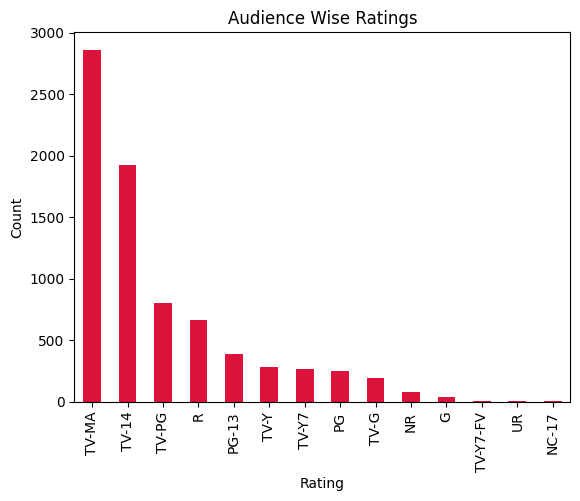

In [ ]:
# Audience wise rating

rating_counts = netflix_df['Rating'].value_counts()

# Plotting the same
rating_counts.plot(kind='bar', color='Crimson')
plt.title('Audience Wise Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


TOP 10 GENRES PREFERRED BY AUDIENCE (MOVIES VS TV SHOWS)

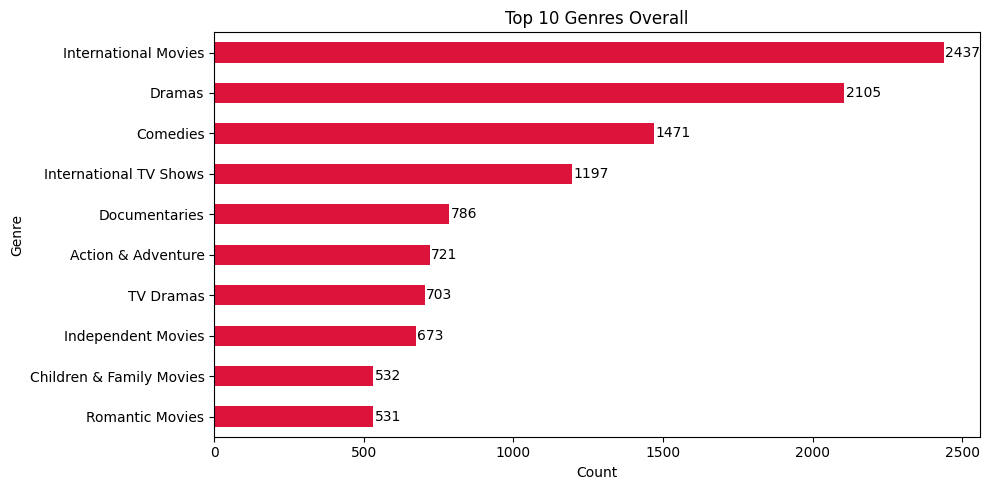

In [ ]:
# Top 10 Genres Preferred by Audience (Movies & TV SHOWS)
top_genres = netflix_df['Type'].dropna().str.split(', ').explode().value_counts().head(10).sort_values(ascending=True)

# Plotting
plt.figure(figsize=(10, 5))
top_genres.plot(kind='barh', color='Crimson')
plt.title('Top 10 Genres Overall')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.bar_label(plt.gca().containers[0], padding=1)
plt.tight_layout()
plt.show()

TOP 10 HIGHES DURATION OF MOVIES VS TV SHOWS

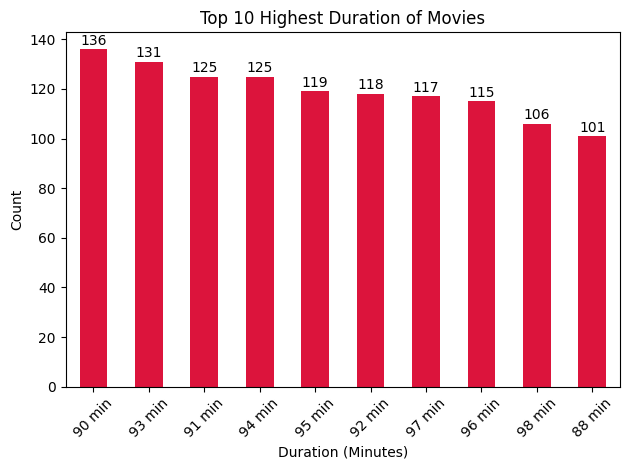

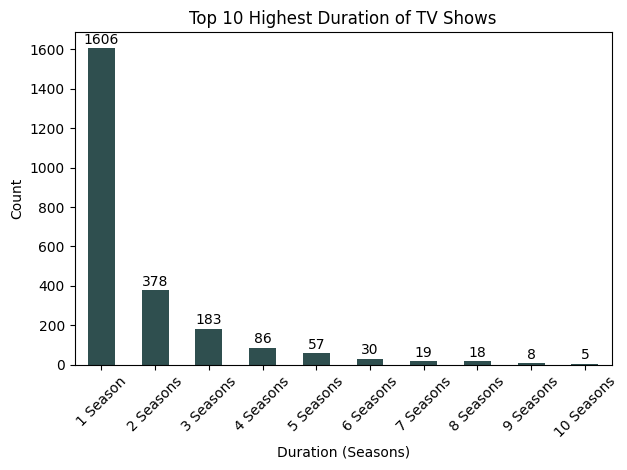

In [ ]:
# Highest Duration of Shows (Movies vs Tv Shows ) (Top 10 Durations)
# Highest Duration for Movies (Top 10 Durations)
movie_duration = netflix_df[netflix_df['Category'] == 'Movie'].groupby('Duration')['Show_Id'].count().sort_values(ascending=False).head(10)

# Plotting Movies Duration
movie_duration.plot(kind='bar', color='Crimson')
plt.title('Top 10 Highest Duration of Movies')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0], padding=1)
plt.tight_layout()
plt.show()

# Highest Duration for TV Shows (Top 10 Durations)
tv_duration = netflix_df[netflix_df['Category'] == 'TV Show'].groupby('Duration')['Show_Id'].count().sort_values(ascending=False).head(10)

# Plotting TV Shows Duration
tv_duration.plot(kind='bar', color='DarkSlateGray')
plt.title('Top 10 Highest Duration of TV Shows')
plt.xlabel('Duration (Seasons)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0], padding=1)
plt.tight_layout()
plt.show()

COUNTRY WISE CONTENT PRODUCTION (TOP 10 COUNTRIES)

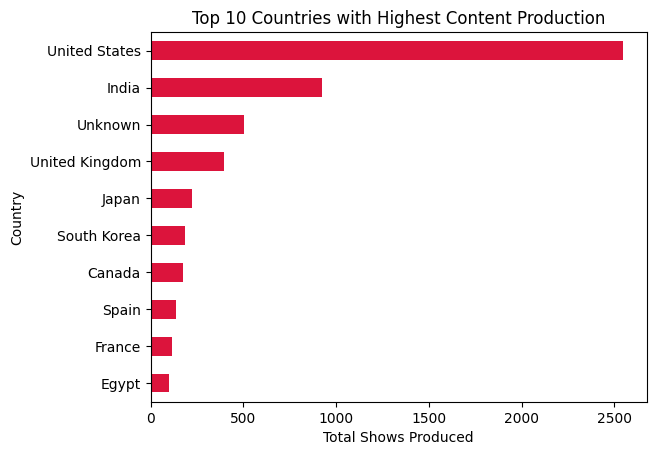

In [ ]:
# Country Wise Content Production (Top 10 Countries)
top_countries = netflix_df['Country'].value_counts().head(10).sort_values(ascending=True)

# Plotting Top Countries
top_countries.plot(kind='barh', color='Crimson')
plt.title('Top 10 Countries with Highest Content Production')
plt.xlabel('Total Shows Produced')
plt.ylabel('Country')
plt.show()

CONTENT TYPE WISE TOP 5 COUNTRIES (MOVIES VS TV SHOWS)

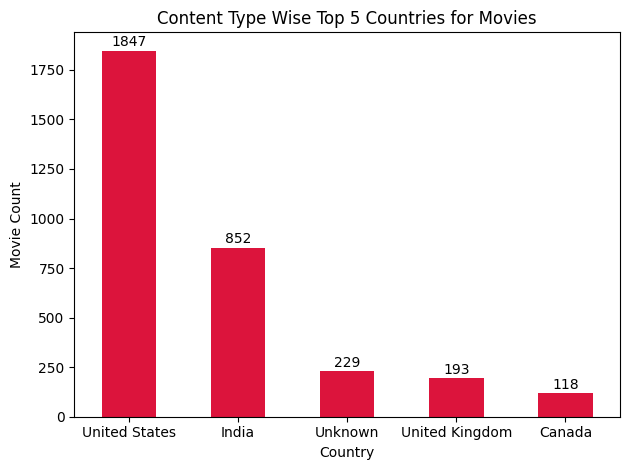

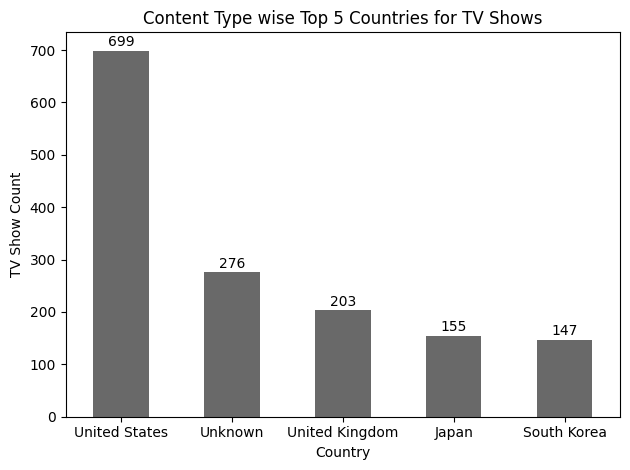

In [ ]:
# Content Type Wise Top Countries Analysis
top_movies = netflix_df[netflix_df['Category'] == 'Movie']['Country'].value_counts().head(5)

top_tv_shows = netflix_df[netflix_df['Category'] == 'TV Show']['Country'].value_counts().head(5)

# Plotting Top Countries for Movies
top_movies.plot(kind='bar', color='Crimson')
plt.title('Content Type Wise Top 5 Countries for Movies')
plt.xlabel('Country')
plt.ylabel('Movie Count')
plt.xticks(rotation=0)
plt.bar_label(plt.gca().containers[0], padding=1)
plt.tight_layout()
plt.show()

# Plotting Top Countries for TV Shows
top_tv_shows.plot(kind='bar', color='DimGrey')
plt.title('Content Type wise Top 5 Countries for TV Shows')
plt.xlabel('Country')
plt.ylabel('TV Show Count')
plt.xticks(rotation=0)
plt.bar_label(plt.gca().containers[0], padding=1)
plt.tight_layout()
plt.show()